# Desafío - Predicción de churn
## Daniel Rojas López

Contexto 

En la industria de las telecomunicaciones, la retención de clientes es un desafío clave para las empresas. La fuga de clientes, también conocida como churn, es un problema que puede tener un impacto significativo en los ingresos y la reputación de una empresa. Anticiparse a la fuga de clientes y tomar medidas preventivas para retenerlos se ha convertido en una prioridad estratégica. En este contexto, el objetivo de esta tarea es utilizar técnicas de machine learning para desarrollar un modelo que pueda predecir la probabilidad de fuga de clientes en una empresa de telecomunicaciones.

El objetivo principal de este proyecto es utilizar un enfoque basado en machine learning para construir un modelo predictivo de fuga de clientes. El modelo será capaz de clasificar a los clientes como "fugados" o "no fugados" en función de un conjunto de variables relevantes. El objetivo es proporcionar a la empresa de telecomunicaciones una herramienta eficaz para identificar a los clientes en riesgo de abandonar sus servicios, lo que permitirá tomar medidas proactivas para retenerlos.

Para lograr este objetivo, se utilizará un conjunto de datos históricos de la base de datos Telco-Customer-Churn.csv que contiene información detallada sobre los clientes como la duración de la suscripción, el uso de servicios, los tipos de servicios contratados, el historial de pagos y más. Estos datos servirán como base para entrenar y validar el modelo predictivo. Se emplearán diversas técnicas de preprocesamiento de datos, selección de características y entrenamiento de modelos de clasificación como árboles de decisión, Naive Bayes o regresión logística, con el fin de obtener el mejor rendimiento posible.

El resultado final será un modelo de clasificación preciso y confiable, capaz de predecir la probabilidad de fuga de clientes en la empresa de telecomunicaciones. Este modelo permitirá a la empresa identificar y priorizar a los clientes en riesgo, lo que a su vez facilitará la implementación de estrategias específicas de retención de clientes. Además, se espera que el proyecto proporcione una comprensión más profunda de los factores y las variables que influyen en la fuga de clientes en la industria de las telecomunicaciones. 

En resumen, este proyecto tiene como objetivo principal aplicar técnicas de machine learning para desarrollar un modelo predictivo de fuga de clientes en la industria de las telecomunicaciones. El modelo resultante permitirá identificar a los clientes en riesgo de abandonar los servicios de la empresa y tomar acciones preventivas para retenerlos. A través de este enfoque, se busca mejorar la retención de clientes, aumentar la satisfacción y mejorar el rendimiento general de la empresa en un entorno altamente competitivo.


1.-Realizar un análisis exploratorio de los datos para comprender las características y la distribución de los datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_excel('Telco-Customer-Churn.xlsx')

# Mostrar las primeras filas
print("Primeras 5 filas del dataset:")
display(df.head())

# Información general del dataset
print("\nInformación del dataset:")
print(df.info())

# Dimensiones del dataset
print(f"\nDimensiones del dataset: {df.shape}")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

# Estadísticas descriptivas
print("\nEstadísticas descriptivas de variables numéricas:")
display(df.describe())

# Estadísticas descriptivas de variables categóricas
print("\nEstadísticas descriptivas de variables categóricas:")
display(df.describe(include=['object']))

# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

Primeras 5 filas del dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000



Estadísticas descriptivas de variables categóricas:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174



Valores nulos por columna:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Tipos de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBi

Distribución de la variable objetivo (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de Churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


C:\Users\drolo\AppData\Local\Temp\ipykernel_14392\2771285664.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


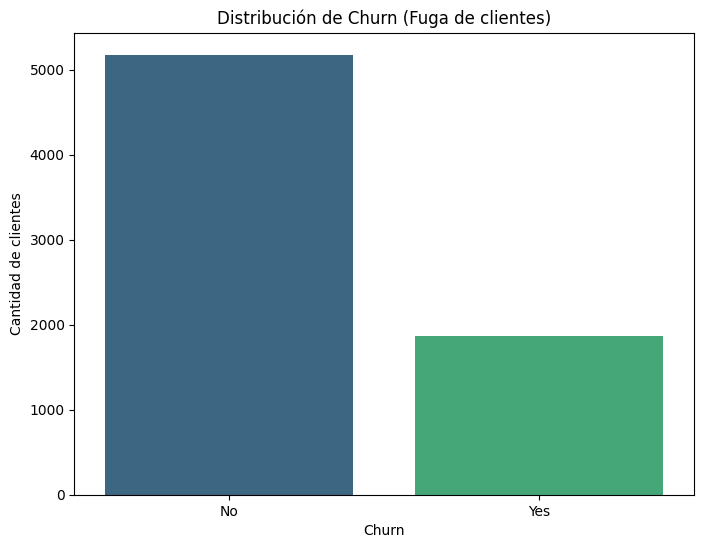

In [2]:
# Análisis de la variable objetivo (Churn)
print("Distribución de la variable objetivo (Churn):")
print(df['Churn'].value_counts())
print(f"\nPorcentaje de Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualización de la distribución de Churn
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de Churn (Fuga de clientes)')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.show()

Variables numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


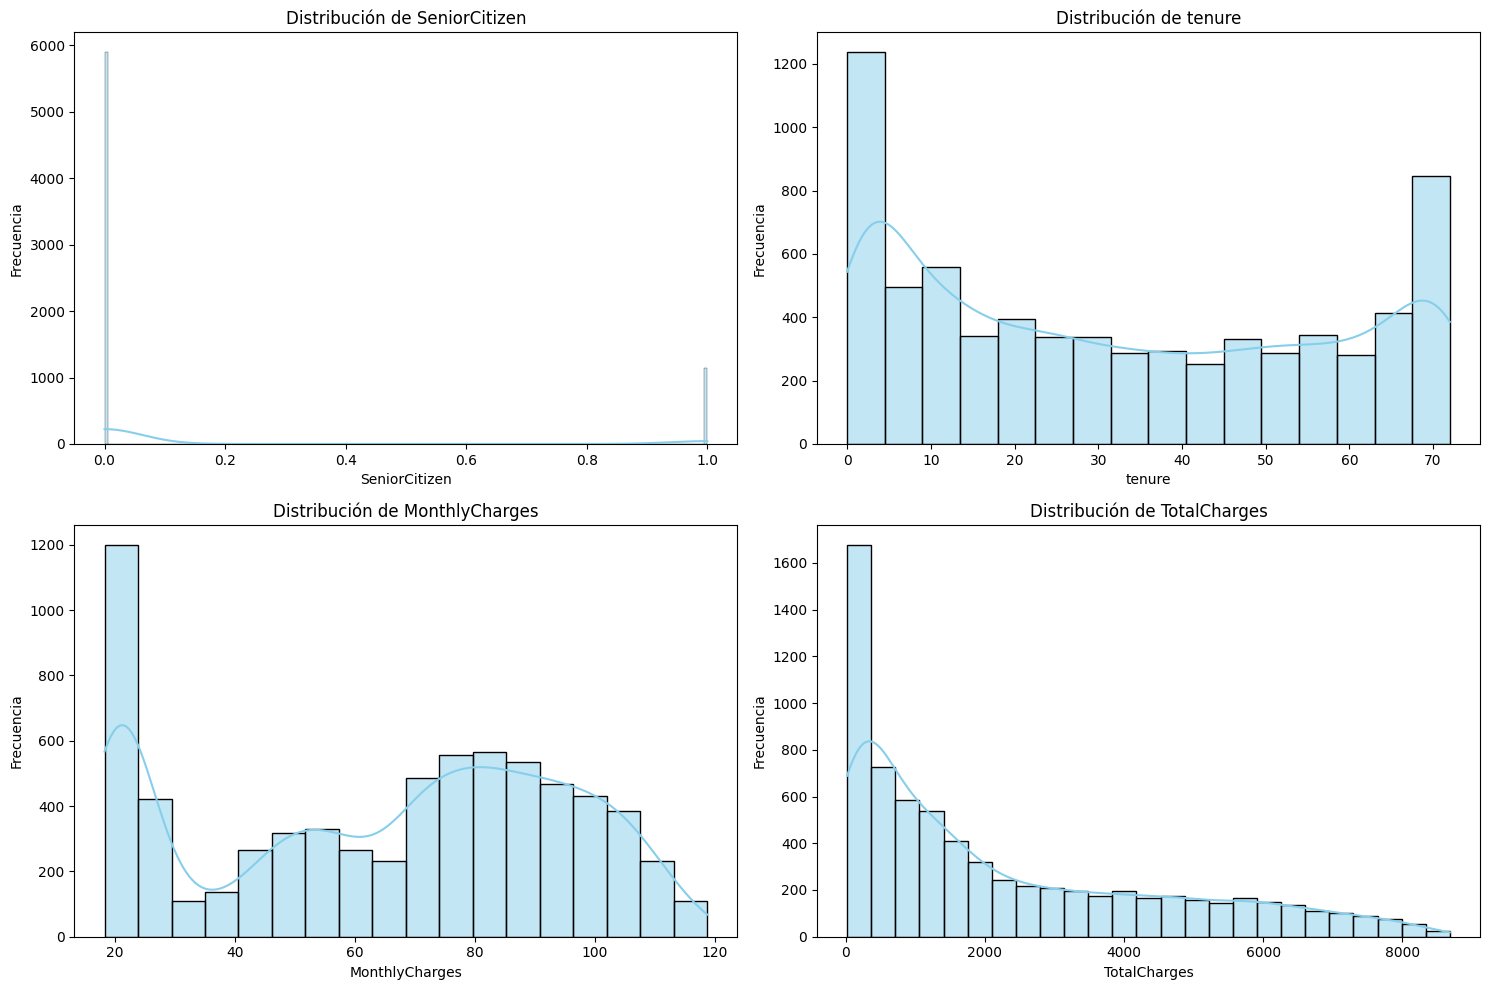

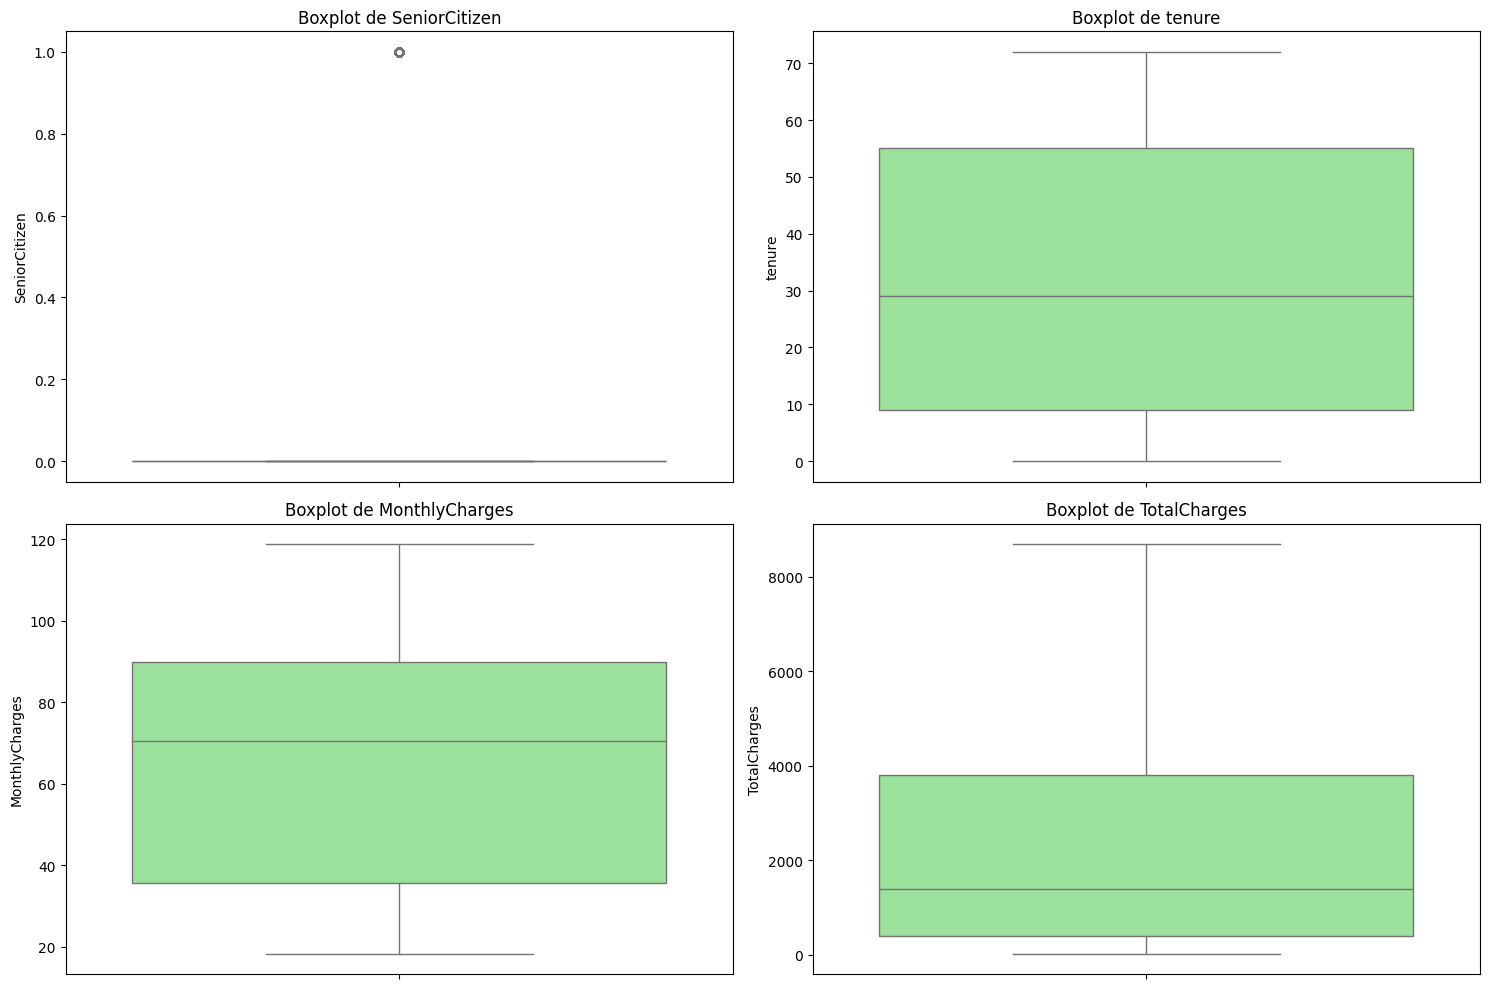

In [3]:
# Análisis de variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables numéricas: {numeric_cols}")

# Histogramas de variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Boxplots de variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
        axes[i].set_title(f'Boxplot de {col}')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [4]:
# Análisis de variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Variables categóricas: {categorical_cols}")
print(f"Número de variables categóricas: {len(categorical_cols)}")

# Mostrar valores únicos para cada variable categórica
print("\nValores únicos por variable categórica:")
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"\n{col}: {len(unique_vals)} valores únicos")
    print(f"  Valores: {list(unique_vals)}")

Variables categóricas: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Número de variables categóricas: 17

Valores únicos por variable categórica:

customerID: 7043 valores únicos
  Valores: ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU', '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU', '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS', '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB', '8779-QRDMV', '1680-VDCWW', '1066-JKSGK', '3638-WEABW', '6322-HRPFA', '6865-JZNKO', '6467-CHFZW', '8665-UTDHZ', '5248-YGIJN', '8773-HHUOZ', '3841-NFECX', '4929-XIHVW', '6827-IEAUQ', '7310-EGVHZ', '3413-BMNZE', '6234-RAAPL', '6047-YHPVI', '6572-ADKRS', '5380-WJKOV', '8168-UQWWF', '8865-TNMNX', '9489-DEDVP', '986

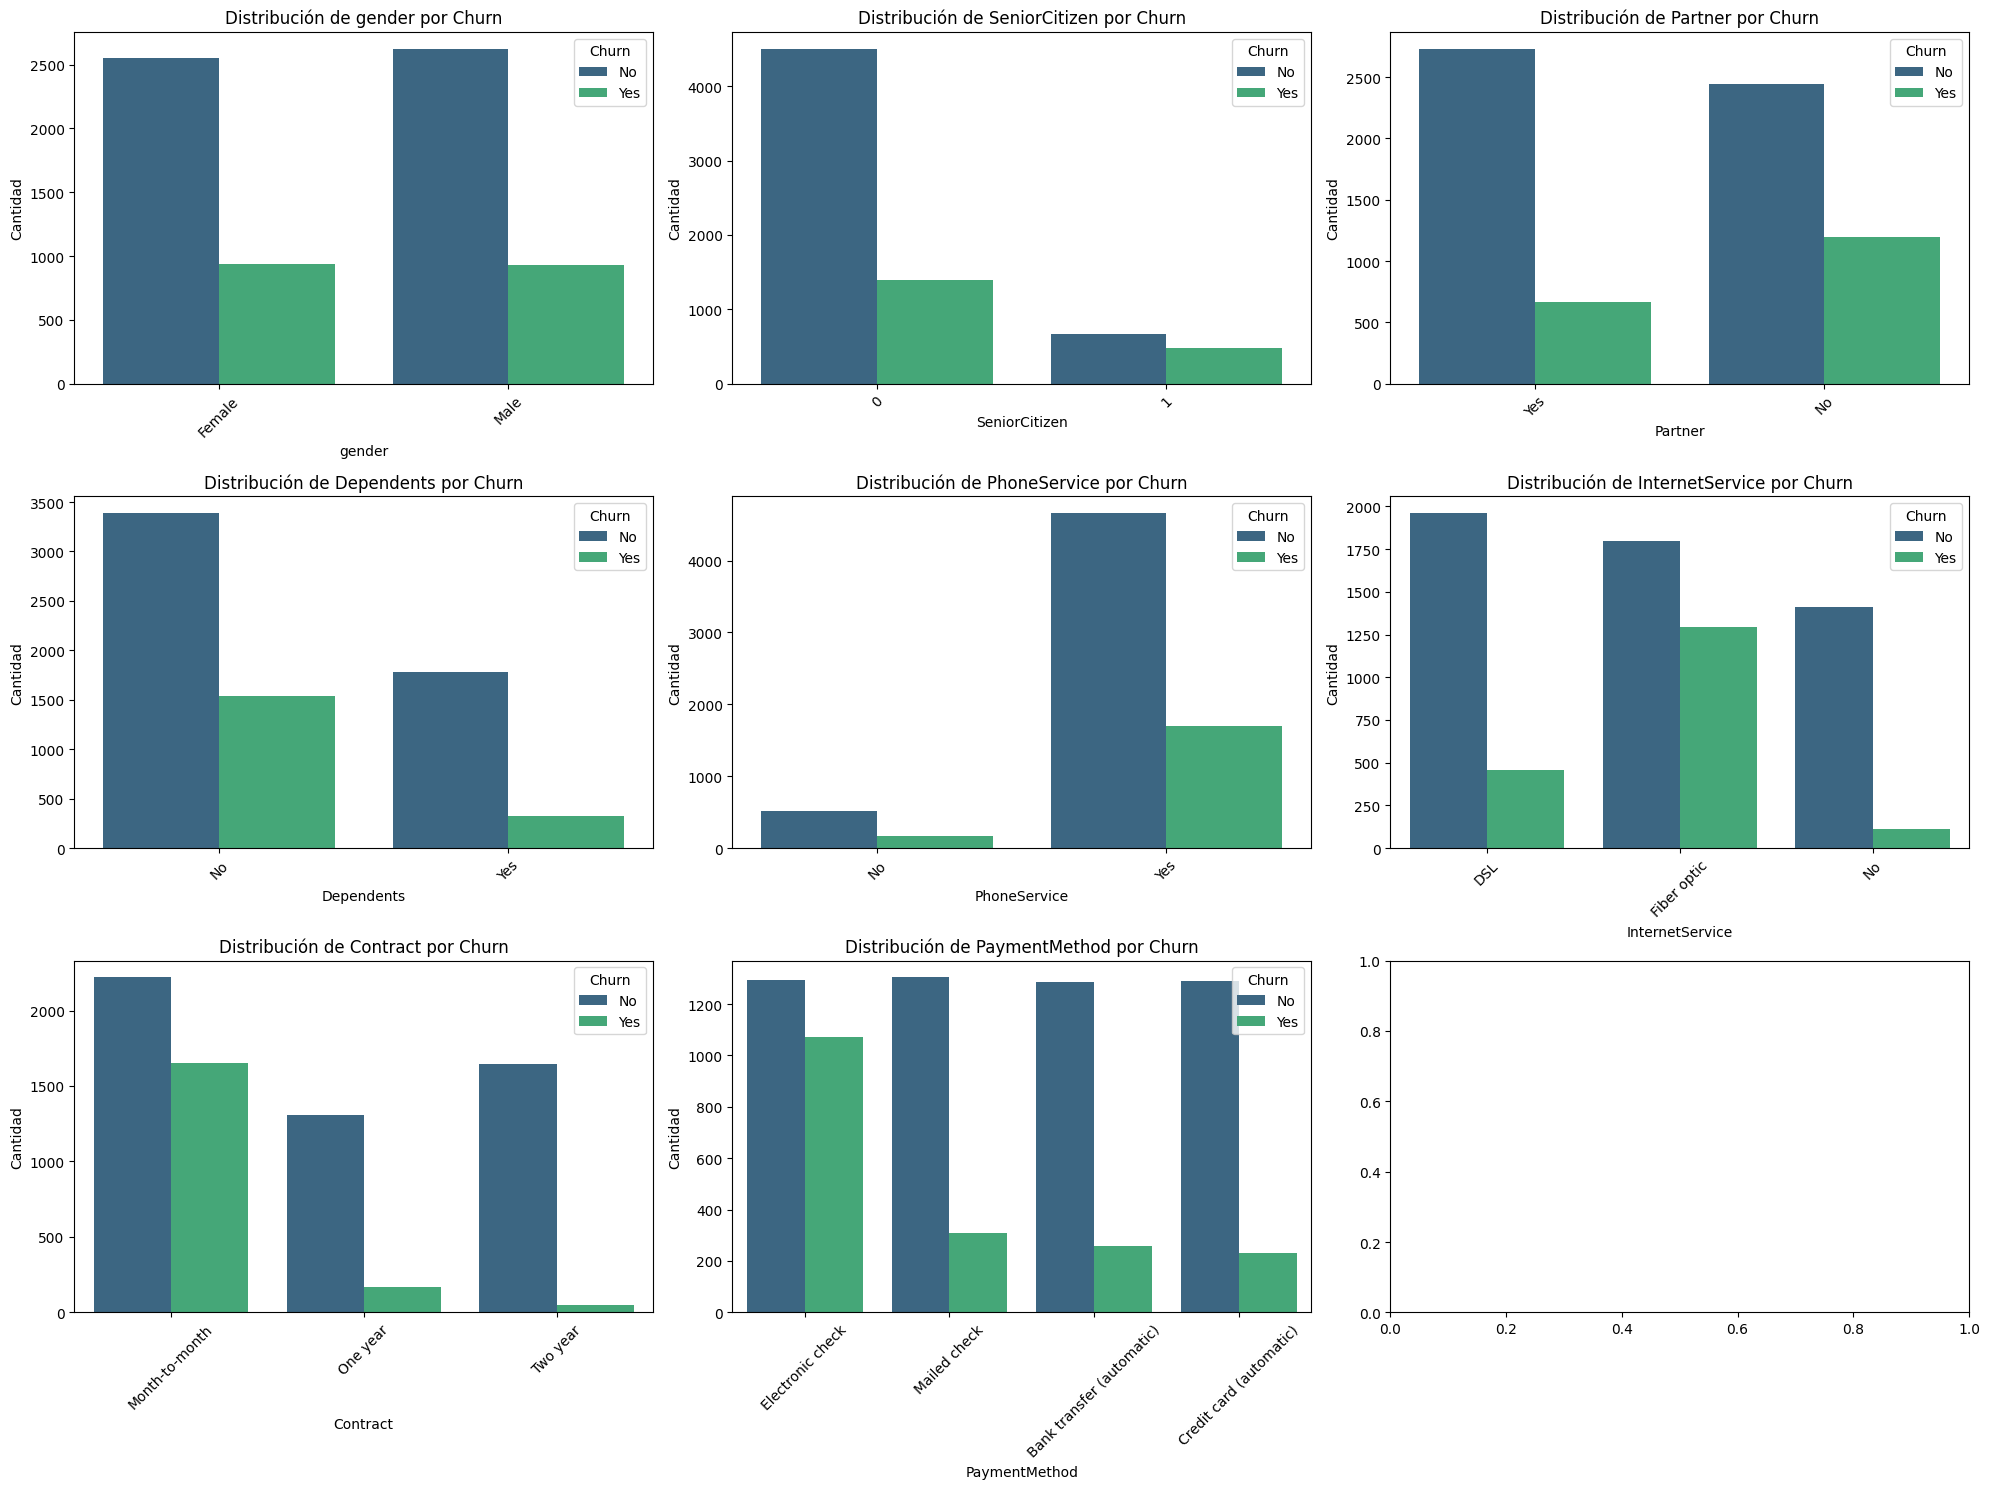

In [5]:
# Análisis de variables categóricas principales vs Churn
key_categorical = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
                   'InternetService', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(key_categorical):
    if i < len(axes):
        sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribución de {col} por Churn')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Cantidad')
        axes[i].legend(title='Churn')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

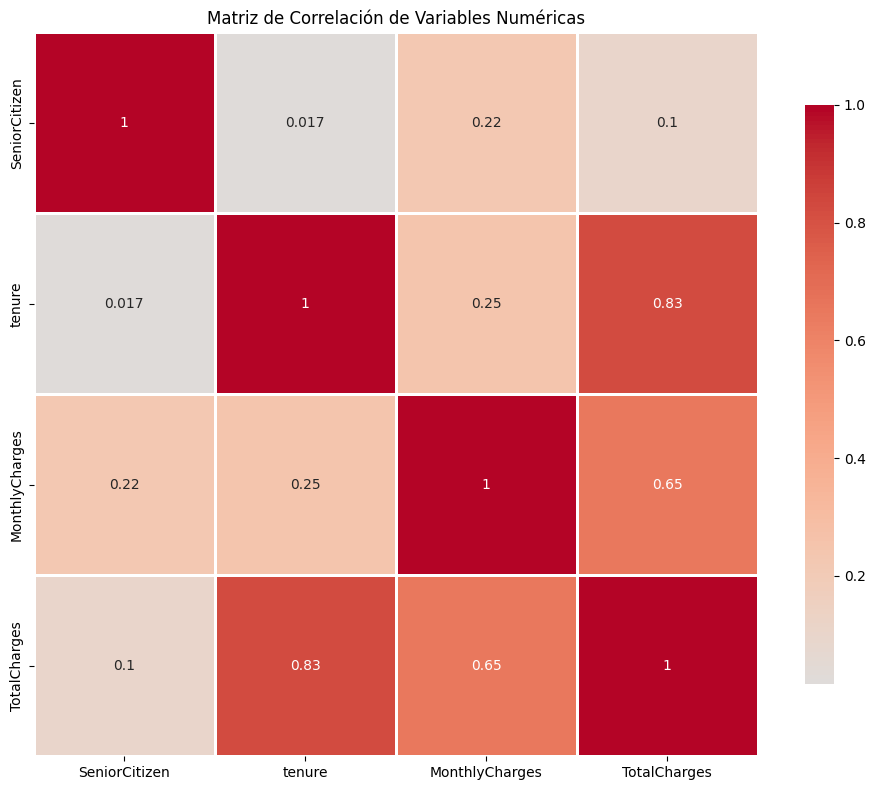

C:\Users\drolo\AppData\Local\Temp\ipykernel_14392\988849733.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='viridis')
C:\Users\drolo\AppData\Local\Temp\ipykernel_14392\988849733.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='viridis')


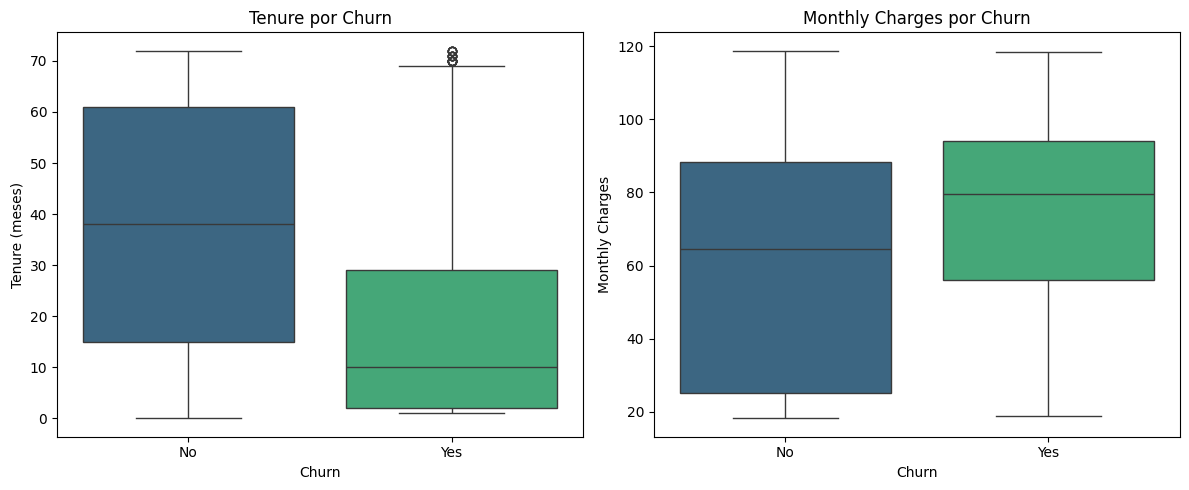

In [6]:
# Análisis de correlación entre variables numéricas
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

# Análisis de tenure vs Monthly Charges vs Churn
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='tenure', data=df, palette='viridis')
plt.title('Tenure por Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (meses)')

plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='viridis')
plt.title('Monthly Charges por Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.tight_layout()
plt.show()

2.-Preprocesar los datos, incluyendo la limpieza, la transformación y la normalización de las características según sea necesario.

In [7]:
# Preprocesamiento de datos

# Verificar valores nulos antes del preprocesamiento
print("Valores nulos antes del preprocesamiento:")
print(df.isnull().sum())

# Verificar valores vacíos o espacios en blanco
print("\nVerificación de valores vacíos por columna:")
for col in df.columns:
    empty_count = (df[col] == ' ').sum()
    if empty_count > 0:
        print(f"{col}: {empty_count} valores vacíos")

# Reemplazar espacios en blanco con NaN
df = df.replace(' ', np.nan)

# Verificar nuevamente valores nulos
print("\nValores nulos después de reemplazar espacios en blanco:")
print(df.isnull().sum())

# Convertir TotalCharges a numérico (puede tener valores vacíos)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Imputar valores nulos en TotalCharges con la mediana
if df['TotalCharges'].isnull().sum() > 0:
    median_total_charges = df['TotalCharges'].median()
    df['TotalCharges'].fillna(median_total_charges, inplace=True)
    print(f"\nValores nulos en TotalCharges imputados con la mediana: {median_total_charges:.2f}")

# Verificar duplicados
duplicates = df.duplicated().sum()
print(f"\nNúmero de filas duplicadas: {duplicates}")

# Eliminar columnas irrelevantes (customerID no aporta información predictiva)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("\nColumna 'customerID' eliminada")

print(f"\nDimensiones después de limpieza inicial: {df.shape}")

Valores nulos antes del preprocesamiento:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Verificación de valores vacíos por columna:

Valores nulos después de reemplazar espacios en blanco:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract       

In [11]:
# Codificación de variables categóricas
from sklearn.preprocessing import LabelEncoder

# Identificar variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Variables categóricas a codificar: {categorical_cols}")

# Codificar la variable objetivo (Churn) primero
le_churn = LabelEncoder()
df['Churn'] = le_churn.fit_transform(df['Churn'])
print(f"\nCodificación de Churn: {dict(zip(le_churn.classes_, le_churn.transform(le_churn.classes_)))}")

# Codificar variables binarias (Yes/No, Male/Female)
binary_mappings = {
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0,
    'Fiber optic': 1,
    'DSL': 0,
    'No phone service': 0,
    'No internet service': 0
}

# Variables binarias conocidas
binary_vars = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for var in binary_vars:
    if var in df.columns:
        df[var] = df[var].map(binary_mappings).fillna(df[var])
        print(f"{var} codificada")

# Codificar variables ordinales (Contract)
contract_mapping = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}
if 'Contract' in df.columns:
    df['Contract'] = df['Contract'].map(contract_mapping)
    print("Contract codificada")

# Codificar variables nominales restantes con One-Hot Encoding
nominal_vars = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'PaymentMethod']

# Verificar cuáles existen en el dataset
nominal_vars = [var for var in nominal_vars if var in df.columns]

print(f"\nVariables nominales para One-Hot Encoding: {nominal_vars}")

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=nominal_vars, drop_first=True)

print(f"\nDimensiones después de One-Hot Encoding: {df_encoded.shape}")
print(f"Número de columnas: {df_encoded.shape[1]}")

Variables categóricas a codificar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Codificación de Churn: {'No': np.int64(0), 'Yes': np.int64(1)}
gender codificada
Partner codificada
Dependents codificada
PhoneService codificada
PaperlessBilling codificada
Contract codificada

Variables nominales para One-Hot Encoding: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']

Dimensiones después de One-Hot Encoding: (7043, 30)
Número de columnas: 30


In [12]:
# Normalización/Escalado de características numéricas
from sklearn.preprocessing import StandardScaler

# Separar características y variable objetivo
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# Identificar variables numéricas para escalar
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
numeric_features = [f for f in numeric_features if f in X.columns]

print(f"\nVariables numéricas a escalar: {numeric_features}")

# Aplicar StandardScaler
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("\nEstadísticas después del escalado:")
print(X[numeric_features].describe())

# Verificar que no haya valores nulos después del preprocesamiento
print(f"\nValores nulos en X: {X.isnull().sum().sum()}")
print(f"Valores nulos en y: {y.isnull().sum()}")

# Mostrar el dataset final preprocesado
print("\nPrimeras filas del dataset preprocesado:")
display(X.head())

print(f"\nDataset final preprocesado: {X.shape[0]} filas, {X.shape[1]} columnas")

Dimensiones de X: (7043, 29)
Dimensiones de y: (7043,)

Variables numéricas a escalar: ['tenure', 'MonthlyCharges', 'TotalCharges']

Estadísticas después del escalado:
             tenure  MonthlyCharges  TotalCharges
count  7.043000e+03    7.043000e+03  7.043000e+03
mean  -2.421273e-17   -6.406285e-17 -1.488074e-17
std    1.000071e+00    1.000071e+00  1.000071e+00
min   -1.318165e+00   -1.545860e+00 -9.991203e-01
25%   -9.516817e-01   -9.725399e-01 -8.298459e-01
50%   -1.372744e-01    1.857327e-01 -3.904632e-01
75%    9.214551e-01    8.338335e-01  6.642871e-01
max    1.613701e+00    1.794352e+00  2.826743e+00

Valores nulos en X: 0
Valores nulos en y: 0

Primeras filas del dataset preprocesado:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,0,1,-1.160323,-0.994242,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.066327,1,1,0,-0.259629,-0.173244,...,True,False,False,False,False,False,False,False,False,True
2,1,0,0,0,-1.236724,1,0,1,-0.362660,-0.959674,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.514251,0,1,0,-0.746535,-0.194766,...,True,False,True,False,False,False,False,False,False,False
4,0,0,0,0,-1.236724,1,0,1,0.197365,-0.940470,...,False,False,False,False,False,False,False,False,True,False



Dataset final preprocesado: 7043 filas, 29 columnas


3.-Dividir los datos en conjuntos de entrenamiento y prueba.

In [13]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usamos 80% para entrenamiento y 20% para prueba
# stratify=y asegura que la proporción de clases se mantenga en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensiones de los conjuntos de datos:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# Verificar la distribución de clases en los conjuntos
print("\nDistribución de clases en y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución de clases en y_test:")
print(y_test.value_counts(normalize=True) * 100)

Dimensiones de los conjuntos de datos:
X_train: (5634, 29)
X_test: (1409, 29)
y_train: (5634,)
y_test: (1409,)

Distribución de clases en y_train:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Distribución de clases en y_test:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


4.-Entrenar al menos 3 algoritmos y optimizar sus hiperparámetros   

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Definir los modelos a entrenar
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Definir los hiperparámetros para cada modelo
param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10]
    }
}

# Entrenar y optimizar cada modelo
best_models = {}
best_params = {}
cv_results = {}

print("=== Entrenamiento y Optimización de Modelos ===\n")

for model_name, model in models.items():
    print(f"--- {model_name} ---")
    
    # Configurar GridSearchCV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    
    # Entrenar con búsqueda de hiperparámetros
    grid_search.fit(X_train, y_train)
    
    # Guardar el mejor modelo y parámetros
    best_models[model_name] = grid_search.best_estimator_
    best_params[model_name] = grid_search.best_params_
    cv_results[model_name] = grid_search.cv_results_
    
    # Mostrar resultados
    print(f"Mejores hiperparámetros: {grid_search.best_params_}")
    print(f"Mejor score CV: {grid_search.best_score_:.4f}")
    print(f"Score en entrenamiento: {grid_search.score(X_train, y_train):.4f}")
    print(f"Score en prueba: {grid_search.score(X_test, y_test):.4f}")
    print()

# Resumen de los mejores modelos
print("=== Resumen de Modelos Optimizados ===\n")
for model_name in models.keys():
    print(f"{model_name}:")
    print(f"  Mejores parámetros: {best_params[model_name]}")
    print(f"  Accuracy CV: {cv_results[model_name]['mean_test_score'].max():.4f}")
    print()

5.-Evaluar el rendimiento de los modelos utilizando métricas de evaluación pertinentes, como precisión, sensibilidad, valor F1, entre otras.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar cada modelo optimizado
print("=== Evaluación de Modelos ===\n")

results = {}
predictions = {}
probabilities = {}

for model_name, model in best_models.items():
    # Realizar predicciones
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    predictions[model_name] = y_pred
    probabilities[model_name] = y_pred_proba
    
    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Calcular AUC-ROC si el modelo soporta probabilidades
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    # Mostrar resultados
    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensibilidad): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC: {roc_auc:.4f}")
    print()

# Crear DataFrame con resultados comparativos
import pandas as pd
results_df = pd.DataFrame(results).T
print("=== Comparación de Modelos ===")
print(results_df)

# Visualizar métricas comparativas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
axes[0, 0].bar(results_df.index, results_df['Accuracy'], color='skyblue')
axes[0, 0].set_title('Accuracy por Modelo')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylim([0, 1])

# Precision
axes[0, 1].bar(results_df.index, results_df['Precision'], color='lightgreen')
axes[0, 1].set_title('Precision por Modelo')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylim([0, 1])

# Recall
axes[1, 0].bar(results_df.index, results_df['Recall'], color='salmon')
axes[1, 0].set_title('Recall por Modelo')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim([0, 1])

# F1-Score
axes[1, 1].bar(results_df.index, results_df['F1-Score'], color='plum')
axes[1, 1].set_title('F1-Score por Modelo')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Matrices de confusión para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, (model_name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=['No Churn', 'Churn'], 
                yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(f'Matriz de Confusión - {model_name}')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

# Curvas ROC para modelos que soportan probabilidades
plt.figure(figsize=(10, 8))

for model_name, y_pred_proba in probabilities.items():
    if y_pred_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Reporte de clasificación detallado para el mejor modelo
best_model_name = results_df['F1-Score'].idxmax()
print(f"\n=== Reporte de Clasificación Detallado - Mejor Modelo: {best_model_name} ===")
print(classification_report(y_test, predictions[best_model_name], 
                          target_names=['No Churn', 'Churn']))

In [ ]:
# Análisis adicional: Importancia de características y curvas de aprendizaje

# Importancia de características para Random Forest y Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Random Forest Feature Importance
if 'Random Forest' in best_models:
    rf_model = best_models['Random Forest']
    feature_importance_rf = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
    
    sns.barplot(x='Importance', y='Feature', data=feature_importance_rf, 
                palette='viridis', ax=axes[0])
    axes[0].set_title('Top 15 Características Importantes - Random Forest')
    axes[0].set_xlabel('Importancia')

# Gradient Boosting Feature Importance
if 'Gradient Boosting' in best_models:
    gb_model = best_models['Gradient Boosting']
    feature_importance_gb = pd.DataFrame({
        'Feature': X.columns,
        'Importance': gb_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
    
    sns.barplot(x='Importance', y='Feature', data=feature_importance_gb, 
                palette='viridis', ax=axes[1])
    axes[1].set_title('Top 15 Características Importantes - Gradient Boosting')
    axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

# Importancia de características para Logistic Regression (coeficientes)
if 'Logistic Regression' in best_models:
    lr_model = best_models['Logistic Regression']
    feature_coef = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': lr_model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False).head(15)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=feature_coef, palette='coolwarm')
    plt.title('Top 15 Coeficientes - Logistic Regression')
    plt.xlabel('Coeficiente')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.tight_layout()
    plt.show()

# Curvas de aprendizaje
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training score', color='blue', marker='o')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    plt.plot(train_sizes, test_mean, label='Cross-validation score', color='red', marker='o')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='red')
    
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy Score')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Curvas de aprendizaje para cada modelo
for model_name, model in best_models.items():
    plot_learning_curve(model, f'Learning Curve - {model_name}', X_train, y_train)

# Análisis de errores: casos donde el mejor modelo falló
best_model_name = results_df['F1-Score'].idxmax()
best_model = best_models[best_model_name]
y_pred_best = predictions[best_model_name]

# Identificar falsos positivos y falsos negativos
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_best,
    'Probability': probabilities[best_model_name]
})

false_positives = errors_df[(errors_df['Actual'] == 0) & (errors_df['Predicted'] == 1)]
false_negatives = errors_df[(errors_df['Actual'] == 1) & (errors_df['Predicted'] == 0)]

print(f"=== Análisis de Errores - {best_model_name} ===")
print(f"Falsos Positivos (predijo Churn pero no fue): {len(false_positives)}")
print(f"Falsos Negativos (predijo No Churn pero sí fue): {len(false_negatives)}")
print(f"\nPorcentaje de errores en predicciones positivas: {len(false_positives)/(len(false_positives)+sum(y_pred_best==1))*100:.2f}%")
print(f"Porcentaje de errores en predicciones negativas: {len(false_negatives)/(len(false_negatives)+sum(y_pred_best==0))*100:.2f}%")

# Distribución de probabilidades para errores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(false_positives['Probability'], bins=20, alpha=0.7, color='orange', edgecolor='black')
axes[0].set_title('Distribución de Probabilidades - Falsos Positivos')
axes[0].set_xlabel('Probabilidad Predicha de Churn')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(false_negatives['Probability'], bins=20, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Distribución de Probabilidades - Falsos Negativos')
axes[1].set_xlabel('Probabilidad Predicha de Churn')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("\n=== Conclusiones ===")
print(f"El mejor modelo es {best_model_name} con un F1-Score de {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"Este modelo logra un balance adecuado entre precisión ({results_df.loc[best_model_name, 'Precision']:.4f}) y recall ({results_df.loc[best_model_name, 'Recall']:.4f})")
print("El análisis de importancia de características muestra las variables más influyentes en la predicción de churn.")
print("Las curvas de aprendizaje indican si el modelo podría beneficiarse de más datos o si está sobreajustado.")